In [2]:
import pandas as pd
import json
import numpy as np

In [3]:
def process_qualt5_res_individual(_path: str, _cutoff: int, _readability_metric=''):
    _quality_df = pd.read_csv(_path)
    if('readability' in _path):
        _quality_df = _quality_df.rename(columns={'readability_score': 'quality'})
        _quality_df = _quality_df.query('readability_metric==@_readability_metric')
    else:
        _quality_df.quality = _quality_df.quality.apply(lambda x: np.exp(x))
    qualt5_individual_res = _quality_df.query('rank<@_cutoff')[['qid', 'docno', 'rank', 'quality']]

    
    qualt5_individual_res = qualt5_individual_res[qualt5_individual_res.quality != -1]
    qualt5_individual_res_groupby_qid = qualt5_individual_res.groupby(['qid'])['quality']
    _doc_qual_max = dict(zip(qualt5_individual_res_groupby_qid.max().index.astype('str').values, qualt5_individual_res_groupby_qid.max().values))
    _doc_qual_avg = dict(zip(qualt5_individual_res_groupby_qid.mean().index.astype('str').values, qualt5_individual_res_groupby_qid.mean().values))
    _doc_qual_min = dict(zip(qualt5_individual_res_groupby_qid.max().index.astype('str').values, qualt5_individual_res_groupby_qid.min().values))
    return _doc_qual_max, _doc_qual_avg, _doc_qual_min

def process_qualt5_res_integrated(_path: str, _readability_metric=''):
    _quality_df = pd.read_csv(_path)
    if('readability' in _path):
        _quality_df = _quality_df.rename(columns={'score': 'quality'})
        _quality_df = _quality_df.query('readability_metric==@_readability_metric')
    else:
        _quality_df.quality = _quality_df.quality.apply(lambda x: np.exp(x))
        
    qualt5_integrated_res = _quality_df[['qid', 'docno', 'quality']]

    _doc_qual_itg = dict(zip(qualt5_integrated_res.qid.astype('str').values, qualt5_integrated_res.quality.values))
    return _doc_qual_itg

In [4]:
import copy

_k = 2
_ret = 'bm25'
_task = 'nq'
target_metric = 'utility'

if(_task=='nq'):
    _dataset_dev, _dataset_test, _prefix, _suffix = 'nq_dev', ['nq_test'], 'short', 'concise'
elif(_task=='dl'):
    _dataset_dev, _dataset_test, _prefix, _suffix = 'dev_small', ['19', '20'], 'random', 'prompt1'

In [5]:
# loading dev data
f = open(f'../../rag_utility/eval_results/{_prefix}_answers_0shot_1calls_0_0_bm25_dl_{_dataset_dev}_{_suffix}_eval.json')
zero_evals = json.load(f)
f.close()

f = open(f'../../rag_utility/eval_results/{_prefix}_answers_{_k}shot_1calls_1_0_{_ret}_dl_{_dataset_dev}_{_suffix}_eval.json')
k_evals = json.load(f)
f.close()

f = open(f'../../rag_utility/gen_results/{_prefix}_answers_{_k}shot_1calls_1_0_{_ret}_dl_{_dataset_dev}_{_suffix}.json')
k_gens = json.load(f)
f.close()

f = open(f'../perplexity_eval/log_prob_temp_res/full_context_with_query/{_dataset_dev}_{_ret}_{_k}.json')
perpC = json.load(f)
f.close()

f = open(f'../perplexity_eval/log_prob_temp_res/individual_with_query/{_dataset_dev}_{_ret}_20.json')
perpC_indi = json.load(f)
f.close()
top_k_perpC_dict = {i[0]: [sub_i[1] for sub_i in i[1].items() if int(sub_i[0])<_k] for i in perpC_indi.items()}
avg_indi_perpC_dict = {i[0]:np.mean(i[1]) for i in top_k_perpC_dict.items()}
max_indi_perpC_dict = {i[0]:np.max(i[1]) for i in top_k_perpC_dict.items()}
min_indi_perpC_dict = {i[0]:np.min(i[1]) for i in top_k_perpC_dict.items()}

readability_res_path = f'../readability_eval/readability_res/individual_readability_{_dataset_dev}_{_ret}_top_10.csv'
readability_res_path_itg = f'../readability_eval/readability_res/integrated_readability_{_dataset_dev}_{_ret}_top_{_k}.csv'
available_metrics = pd.read_csv(readability_res_path).readability_metric.unique()
readability_max_dict, readability_min_dict, readability_avg_dict, readability_itg_dict = {}, {}, {}, {}
for _r_m in available_metrics:
    _r_m_max, _r_m_avg, _r_m_min = process_qualt5_res_individual(readability_res_path, _k, _r_m)
    _r_m_itg = process_qualt5_res_integrated(readability_res_path_itg, _r_m)
    readability_max_dict.update({_r_m: copy.deepcopy(_r_m_max)})
    readability_min_dict.update({_r_m: copy.deepcopy(_r_m_min)})
    readability_avg_dict.update({_r_m: copy.deepcopy(_r_m_avg)})
    readability_itg_dict.update({_r_m: copy.deepcopy(_r_m_itg)})

doc_qual_max, doc_qual_avg, doc_qual_min = process_qualt5_res_individual(f'../qualt5_eval/quality_res/{_ret}_{_dataset_dev}.csv', _k)
doc_qual_itg = process_qualt5_res_integrated(f'../qualt5_eval/quality_res/{_ret}_{_dataset_dev}_integrated_{_k}.csv')

qpp_df = pd.read_csv(f'./precomputed_qpps/{_ret}_{_k}_combined_qpp_{_dataset_dev}.csv')

dev_res = qpp_df[['qid', 'query']].drop_duplicates().copy()

# Expand the dataframe for the convenience of analysis
for qpp_name in qpp_df.qpp_method.unique():
    value_dict = dict(zip(qpp_df[qpp_df.qpp_method==qpp_name]['qid'], qpp_df[qpp_df.qpp_method==qpp_name]['qpp_estimate']))
    dev_res[qpp_name] = dev_res.qid.apply(lambda _qid: value_dict[_qid])

if(_task=='nq'):
    base_f1_dict = {item[0]: item[1]['0']['0']['F1'] for item in zero_evals.items()}
    f1_dict = {item[0]: item[1]['0']['0']['F1'] for item in k_evals.items()}
    # em_dict = {item[0]: item[1]['0']['0']['EM'] for item in k_evals.items()}
    kshot_prob_dict = {item[0]: np.mean(eval(item[1]['0']['0']['probs'])) for item in k_gens.items()}
elif(_task=='dl'):
    base_f1_dict = {item[0]: item[1]['0']['0']['qrel_1']['f1']['max'] for item in zero_evals.items() if ('0' in item[1].keys())}
    f1_dict = {item[0]: item[1]['0']['0']['qrel_1']['f1']['max'] for item in k_evals.items() if ('0' in item[1].keys())}
    kshot_prob_dict = {item[0]: np.mean(eval(item[1]['0']['0']['probs'])) for item in k_gens.items() if ('0' in item[1].keys())}

dev_res = dev_res[dev_res.qid.astype('str').isin(f1_dict.keys())]
dev_res['f1'] = dev_res.qid.apply(lambda x: f1_dict[str(x)])
dev_res['utility'] = dev_res.qid.apply(lambda x: f1_dict[str(x)]-base_f1_dict[str(x)])
# dev_res['em'] = dev_res.qid.apply(lambda x: em_dict[str(x)])
dev_res['prob(k)'] = dev_res.qid.apply(lambda x: kshot_prob_dict[str(x)])

dev_res['max(perpC)'] = dev_res.qid.apply(lambda x: max_indi_perpC_dict[str(x)])
dev_res['min(perpC)'] = dev_res.qid.apply(lambda x: min_indi_perpC_dict[str(x)])
dev_res['avg(perpC)'] = dev_res.qid.apply(lambda x: avg_indi_perpC_dict[str(x)])
dev_res['itg(perpC)'] = dev_res.qid.apply(lambda x: perpC[str(x)])

dev_res['max(docQual)'] = dev_res.qid.apply(lambda x: doc_qual_max[str(x)])
dev_res['min(docQual)'] = dev_res.qid.apply(lambda x: doc_qual_min[str(x)])
dev_res['avg(docQual)'] = dev_res.qid.apply(lambda x: doc_qual_avg[str(x)])
dev_res['itg(docQual)'] = dev_res.qid.apply(lambda x: doc_qual_itg[str(x)])
print(dev_res.shape)
dev_res = dev_res[dev_res.qid.astype('str').isin(readability_itg_dict['Spache'].keys())]
print(dev_res.shape)

readability_cols = []
for _r_m in available_metrics:
    readability_cols += [f'max({_r_m})', f'min({_r_m})', f'avg({_r_m})', f'itg({_r_m})']
    print(_r_m, len(readability_max_dict[_r_m]))

    for qid in dev_res.qid.unique():
        if qid not in readability_max_dict[_r_m].keys():
            # print(qid)
            readability_max_dict[_r_m].update({str(qid): -1})
            readability_min_dict[_r_m].update({str(qid): -1})
            readability_avg_dict[_r_m].update({str(qid): -1})
        if qid not in readability_itg_dict[_r_m].keys():
            readability_itg_dict[_r_m].update({str(qid): -1})
    
    dev_res[f'max({_r_m})'] = dev_res.qid.apply(lambda x: readability_max_dict[_r_m][str(x)])
    dev_res[f'min({_r_m})'] = dev_res.qid.apply(lambda x: readability_min_dict[_r_m][str(x)])
    dev_res[f'avg({_r_m})'] = dev_res.qid.apply(lambda x: readability_avg_dict[_r_m][str(x)])
    dev_res[f'itg({_r_m})'] = dev_res.qid.apply(lambda x: readability_itg_dict[_r_m][str(x)])

dev_res = dev_res.drop(columns=[col for col in readability_cols if (dev_res[col] == -1).any()])
dev_res = dev_res.dropna(axis=1)

dev_res = dev_res.dropna(axis='index')
dev_res.head(3)


(8757, 19)
(8757, 19)
Dale Chall 8702
Spache 8702
Flesch-Kincaid 8702
Flesch 8702
Gunning Fog 8702
Coleman Liau 8702
ARI 8702
Linsear Write 8702
SMOG 0


,qid,query,nqc,maxScore,spatial,a_ratio,bertQPP,bertQPP(QV),f1,utility,...,avg(docQual),itg(docQual),itg(Dale Chall),itg(Spache),itg(Flesch-Kincaid),itg(Flesch),itg(Gunning Fog),itg(Coleman Liau),itg(ARI),itg(Linsear Write)
0,dev_0,who sings does he love me with reba,481.661523,45.141166,2899.000977,1.278711,0.099205,0.176757,0.0,0.0,...,0.412626,0.385534,8.123668,6.980129,9.462790,71.450136,11.316184,6.689662,10.438514,13.562500
1,dev_1,how many pages is invisible man by ralph ellison,6.961528,58.141517,3008.982910,1.175171,0.314335,0.303146,0.0,0.0,...,0.512101,0.560949,10.327608,7.171123,9.779091,59.450455,10.955610,7.710090,8.667801,13.090909
2,dev_10,who is the bad guy in lord of the rings,182.644118,40.977722,2799.475586,1.191295,0.108985,0.152203,0.0,-1.0,...,0.477328,0.592480,10.239306,7.429949,9.298670,61.962424,10.447138,7.818704,8.514710,12.090909


In [6]:
# loading test data

import numpy as np

def tool_for_aggregating_dl_performance(x):
    # the same as performLoader
    scores = []
    for answer_eval in x[1]['0'].values():
        scores.append(max(answer_eval['qrel_2']['f1']['max'], answer_eval['qrel_3']['f1']['max']))
    return np.mean(scores)

zero_evals, k_evals, k_gens, perpC  = {}, {}, {}, {}

_calls = 5 if _task=='dl' else 1

for _d in _dataset_test:
    f = open(f'../../rag_utility/eval_results/{_prefix}_answers_0shot_{_calls}calls_0_0_bm25_dl_{_d}_{_suffix}_eval.json')
    zero_evals.update(json.load(f))
    f.close()
    
    f = open(f'../../rag_utility/eval_results/{_prefix}_answers_{_k}shot_{_calls}calls_1_0_{_ret}_dl_{_d}_{_suffix}_eval.json')
    print(f'../../rag_utility/eval_results/{_prefix}_answers_{_k}shot_{_calls}calls_1_0_{_ret}_dl_{_d}_{_suffix}_eval.json')
    k_evals.update(json.load(f))
    f.close()
    
    f = open(f'../../rag_utility/gen_results/{_prefix}_answers_{_k}shot_{_calls}calls_1_0_{_ret}_dl_{_d}_{_suffix}.json')
    k_gens.update(json.load(f))
    f.close()

if(_task == 'dl'):
    _d = 'dl'
else:
    _d = 'nq_test'
    
f = open(f'../perplexity_eval/log_prob_temp_res/full_context_with_query/{_d}_{_ret}_{_k}.json')
perpC.update(json.load(f))
f.close()

f = open(f'../perplexity_eval/log_prob_temp_res/individual_with_query/{_d}_{_ret}_20.json')
perpC_indi = json.load(f)
f.close()
top_k_perpC_dict = {i[0]: [sub_i[1] for sub_i in i[1].items() if int(sub_i[0])<_k] for i in perpC_indi.items()}
avg_indi_perpC_dict = {i[0]:np.mean(i[1]) for i in top_k_perpC_dict.items()}
max_indi_perpC_dict = {i[0]:np.max(i[1]) for i in top_k_perpC_dict.items()}
min_indi_perpC_dict = {i[0]:np.min(i[1]) for i in top_k_perpC_dict.items()}

readability_res_path = f'../readability_eval/readability_res/individual_readability_{_d}_{_ret}_top_10.csv'
readability_res_path_itg = f'../readability_eval/readability_res/integrated_readability_{_d}_{_ret}_top_{_k}.csv'
available_metrics = pd.read_csv(readability_res_path).readability_metric.unique()
readability_max_dict, readability_avg_dict, readability_itg_dict, readability_min_dict = {}, {}, {}, {}
for _r_m in available_metrics:
    _r_m_max, _r_m_avg, _r_m_min = process_qualt5_res_individual(readability_res_path, _k, _r_m)
    _r_m_itg = process_qualt5_res_integrated(readability_res_path_itg, _r_m)
    readability_max_dict.update({_r_m: copy.deepcopy(_r_m_max)})
    readability_min_dict.update({_r_m: copy.deepcopy(_r_m_min)})
    readability_avg_dict.update({_r_m: copy.deepcopy(_r_m_avg)})
    readability_itg_dict.update({_r_m: copy.deepcopy(_r_m_itg)})

doc_qual_max, doc_qual_avg, doc_qual_min = process_qualt5_res_individual(f'../qualt5_eval/quality_res/{_ret}_{_d}.csv', _k)
doc_qual_itg = process_qualt5_res_integrated(f'../qualt5_eval/quality_res/{_ret}_{_d}_integrated_{_k}.csv')

qpp_df = pd.read_csv(f'./precomputed_qpps/{_ret}_{_k}_combined_qpp_{_d}.csv')

test_res = qpp_df[['qid', 'query']].drop_duplicates().copy()

# Expand the dataframe for the convenience of analysis
for qpp_name in qpp_df.qpp_method.unique():
    value_dict = dict(zip(qpp_df[qpp_df.qpp_method==qpp_name]['qid'], qpp_df[qpp_df.qpp_method==qpp_name]['qpp_estimate']))
    test_res[qpp_name] = test_res.qid.apply(lambda _qid: value_dict[_qid])

if(_task=='nq'):
    base_f1_dict = {item[0]: item[1]['0']['0']['F1'] for item in zero_evals.items()}
    f1_dict = {item[0]: item[1]['0']['0']['F1'] for item in k_evals.items()}
    # em_dict = {item[0]: item[1]['0']['0']['EM'] for item in k_evals.items()}
    kshot_prob_dict = {item[0]: np.mean(eval(item[1]['0']['0']['probs'])) for item in k_gens.items()}
elif(_task=='dl'):
    base_f1_dict = {item[0]: tool_for_aggregating_dl_performance(item) for item in zero_evals.items() if ('0' in item[1].keys())}
    f1_dict = {item[0]: tool_for_aggregating_dl_performance(item) for item in k_evals.items() if ('0' in item[1].keys())}
    kshot_prob_dict = {item[0]: np.mean(eval(item[1]['0']['0']['probs'])) for item in k_gens.items() if ('0' in item[1].keys())}

test_res = test_res[test_res.qid.astype('str').isin(f1_dict.keys())]
test_res['f1'] = test_res.qid.apply(lambda x: f1_dict[str(x)])
test_res['utility'] = test_res.qid.apply(lambda x: f1_dict[str(x)]-base_f1_dict[str(x)])
# test_res['em'] = test_res.qid.apply(lambda x: em_dict[str(x)])
test_res['prob(k)'] = test_res.qid.apply(lambda x: kshot_prob_dict[str(x)])

test_res['max(perpC)'] = test_res.qid.apply(lambda x: max_indi_perpC_dict[str(x)])
test_res['min(perpC)'] = test_res.qid.apply(lambda x: min_indi_perpC_dict[str(x)])
test_res['avg(perpC)'] = test_res.qid.apply(lambda x: avg_indi_perpC_dict[str(x)])
test_res['itg(perpC)'] = test_res.qid.apply(lambda x: perpC[str(x)])

test_res['max(docQual)'] = test_res.qid.apply(lambda x: doc_qual_max[str(x)])
test_res['min(docQual)'] = test_res.qid.apply(lambda x: doc_qual_min[str(x)])
test_res['avg(docQual)'] = test_res.qid.apply(lambda x: doc_qual_avg[str(x)])
test_res['itg(docQual)'] = test_res.qid.apply(lambda x: doc_qual_itg[str(x)])

print(test_res.shape)
test_res = test_res[test_res.qid.astype('str').isin(readability_itg_dict['Spache'].keys())]
print(test_res.shape)

readability_cols = []
for _r_m in available_metrics:
    readability_cols += [f'max({_r_m})', f'min({_r_m})', f'avg({_r_m})', f'itg({_r_m})']
    print(_r_m, len(readability_max_dict[_r_m]))

    for qid in test_res.qid.unique():
        if qid not in readability_max_dict[_r_m].keys():
            # print(qid)
            readability_max_dict[_r_m].update({str(qid): -1})
            readability_min_dict[_r_m].update({str(qid): -1})
            readability_avg_dict[_r_m].update({str(qid): -1})
        if qid not in readability_itg_dict[_r_m].keys():
            readability_itg_dict[_r_m].update({str(qid): -1})
    
    test_res[f'max({_r_m})'] = test_res.qid.apply(lambda x: readability_max_dict[_r_m][str(x)])
    test_res[f'min({_r_m})'] = test_res.qid.apply(lambda x: readability_min_dict[_r_m][str(x)])
    test_res[f'avg({_r_m})'] = test_res.qid.apply(lambda x: readability_avg_dict[_r_m][str(x)])
    test_res[f'itg({_r_m})'] = test_res.qid.apply(lambda x: readability_itg_dict[_r_m][str(x)])

dropped_columns = [col for col in readability_cols if (test_res[col] == -1).any()]
test_res = test_res.drop(columns=[col for col in readability_cols if (test_res[col] == -1).any()])
test_res = test_res.dropna(axis=1)
readability_cols = [e for e in readability_cols if e not in dropped_columns]
test_res.head(3)

../../rag_utility/eval_results/short_answers_2shot_1calls_1_0_bm25_dl_nq_test_concise_eval.json
(3610, 19)
(3610, 19)
Dale Chall 3578
Spache 3578
Flesch-Kincaid 3578
Flesch 3578
Gunning Fog 3578
Coleman Liau 3578
ARI 3578
Linsear Write 3578
SMOG 0


,qid,query,nqc,maxScore,spatial,a_ratio,bertQPP,bertQPP(QV),f1,utility,...,avg(docQual),itg(docQual),itg(Dale Chall),itg(Spache),itg(Flesch-Kincaid),itg(Flesch),itg(Gunning Fog),itg(Coleman Liau),itg(ARI),itg(Linsear Write)
0,test_0,who got the first nobel prize in physics,0.072675,48.869722,3347.613281,1.242982,0.019222,0.058567,0.8,-0.2,...,0.753418,0.531096,10.715389,8.917231,15.095804,42.958913,16.382064,10.937462,17.126058,20.750000
1,test_1,when is the next deadpool movie being released,5.276903,39.520332,2877.293945,1.176165,0.109545,0.217999,0.5,0.5,...,0.639785,0.636881,11.324982,8.287547,10.071451,61.488035,12.933805,7.815221,9.835398,14.100000
2,test_10,what is the most current adobe flash player ve...,0.812393,52.875822,3185.770020,1.108484,0.054718,0.064228,0.0,0.0,...,0.699564,0.710493,12.058254,8.628079,12.389031,46.315666,12.979674,10.832607,12.636819,14.611111


In [7]:
from scipy import stats

In [8]:
import pandas as pd

corr = test_res.drop(columns=['qid', 'query', 'f1', 'utility', 'bertQPP(QV)']).corr(method="spearman")

df_content = []
for predictor_name in corr:
    df_content.append([predictor_name, stats.spearmanr(test_res[predictor_name], test_res[target_metric])[0], stats.kendalltau(test_res[predictor_name], test_res[target_metric])[0]])

a1 = pd.DataFrame(df_content, columns=['QPP_Method', 'Spearman', 'Kendall'])
a1.Spearman = a1.Spearman.apply(lambda x: round(x, 4))
a1.Kendall = a1.Kendall.apply(lambda x: round(x, 4))
a1.to_csv('./temp_for_pasting_results/a1.csv', index=False)
a1

,QPP_Method,Spearman,Kendall
0,nqc,0.0694,0.0517
1,maxScore,0.1485,0.1103
2,spatial,0.1739,0.1291
3,a_ratio,0.1565,0.1166
4,bertQPP,0.1898,0.1416
5,prob(k),0.1468,0.1095
6,max(perpC),0.0935,0.0687
7,min(perpC),0.0649,0.0478
8,avg(perpC),0.0860,0.0634
9,itg(perpC),0.0884,0.0653


#### Learned Combination -> Linear Regression

In [9]:
# keep dev and test data having the same features
common_cols = test_res.columns.intersection(dev_res.columns)

test_res = test_res[common_cols]
dev_res = dev_res[common_cols]

In [10]:
from sklearn import linear_model
import itertools
import pathlib

output_content = []

output_path = "./ecir_res/union_output_v1.csv"

# all_ablations = ['0', '1', '2', '3', '01', '02', '03', '12', '13', '23', '012', '013', '023', '123', '0123']
all_ablations = ['0123']

# define features
for use_postgen, pregen_combination in itertools.product([False], all_ablations):
    
    print(pregen_combination, use_postgen)
    used_qpp_methods = ['nqc', 'spatial', 'maxScore', 'a_ratio', 'bertQPP']

    used_predictors_unchanged, used_predictors_need_log = [], []
    # used_reader_centric_predictors = []
    if('0' in pregen_combination):
        used_predictors_need_log += used_qpp_methods
    if('1' in pregen_combination):
        used_predictors_unchanged += ['max(perpC)', 'avg(perpC)', 'itg(perpC)']
    if('2' in pregen_combination):
        used_predictors_need_log += ['max(docQual)', 'avg(docQual)', 'itg(docQual)']
    if('3' in pregen_combination):
        used_predictors_unchanged += readability_cols

    # if(target_metric=='utility'):
    #     dev_res = pd.concat([dev_res[dev_res.utility<0], dev_res[dev_res.utility>0.5]])

    # print(used_predictors_unchanged)
    # print(used_predictors_need_log)
    # load data
    dev_data_0, dev_data_1, test_data_0, test_data_1 = 0, 0, 0, 0
    if(used_predictors_unchanged != []):
        dev_data_0 = dev_res[used_predictors_unchanged]
        test_data_0 = test_res[used_predictors_unchanged]
    if(used_predictors_need_log != []):
        dev_data_1 = dev_res[used_predictors_need_log].apply(lambda x: np.log(1+x))
        test_data_1 = test_res[used_predictors_need_log].apply(lambda x: np.log(1+x))

    if(used_predictors_unchanged == []):
        dev_data, test_data = dev_data_1, test_data_1
    elif(used_predictors_need_log == []):
        dev_data, test_data = dev_data_0, test_data_0
    else:
        dev_data, test_data = np.hstack((dev_data_0, dev_data_1)), np.hstack((test_data_0, test_data_1))
        
    if(use_postgen):
        dev_data = np.hstack((dev_data, dev_res[['prob(k)']].values))
        test_data = np.hstack((test_data, test_res[['prob(k)']].values))

    # best before combination
    best_row = a1[a1.QPP_Method.isin(used_predictors_unchanged+used_predictors_need_log+use_postgen*['prob(k)'])].query('Spearman==Spearman.max()').iloc[0]
    print(f'Best before combination is {best_row.QPP_Method}, rho={best_row.Spearman}, tau={best_row.Kendall}')
    
    # linear regression
    reg = linear_model.LinearRegression()

    reg.fit(dev_data, dev_res[target_metric].values)
    coefs = reg.coef_
    intercept = reg.intercept_
    predictions = (dev_data * coefs).sum(axis=1) + intercept
    
    # print(coefs)
    # print(intercept)
    # print('accuracy on Dev set', stats.spearmanr(predictions, dev_res[target_metric]))
    
    try:
        f = open('./temp_for_pasting_results/weights.json', 'r+', encoding='UTF-8')
        weights = json.load(f)
        f.close()
    except:
        weights = {}
    
    weights.update({f'{_k}-{_ret}-{_task}-{target_metric}': list(coefs)})
    f = open('./temp_for_pasting_results/weights.json', 'w+')
    json.dump(weights, f, indent=4)
    f.close()
    
    predictions_test = ((test_data * coefs).sum(axis=1) + intercept)

    result_rho, result_tau = stats.spearmanr(predictions_test, test_res[target_metric])[0], stats.kendalltau(predictions_test, test_res[target_metric])[0]
    print(f'Accuracy on Test set, rho={result_rho}, tau={result_tau}')
    output_content.append(['GPP' if target_metric=='f1' else 'RPP', _task, _ret, _k, use_postgen, pregen_combination, result_rho, result_tau, best_row.QPP_Method, best_row.Spearman, best_row.Kendall])

    
    
temp_output = pd.DataFrame(output_content, columns=['Prediction Name', 'QA Task', 'Retriever', 'Top-Retrieved Docs', 'Use_Postgen', 'Combination_Number', 'Rho', 'Tau', 'Best Single Signal', 'Best Single Rho', 'Best Single Tau'])
# csvfile = pathlib.Path(output_path)
# temp_output.to_csv(output_path, mode='a', index=False, header=not csvfile.exists())
# # deduplicate
# x = pd.read_csv(output_path)
# x = x.drop_duplicates()
# x.to_csv(output_path, index=False)

temp_output

0123 False
Best before combination is bertQPP, rho=0.1898, tau=0.1416
Accuracy on Test set, rho=0.23796404802736887, tau=0.17729844110557558


,Prediction Name,QA Task,Retriever,Top-Retrieved Docs,Use_Postgen,Combination_Number,Rho,Tau,Best Single Signal,Best Single Rho,Best Single Tau
0,RPP,nq,bm25,2,False,0123,0.237964,0.177298,bertQPP,0.1898,0.1416


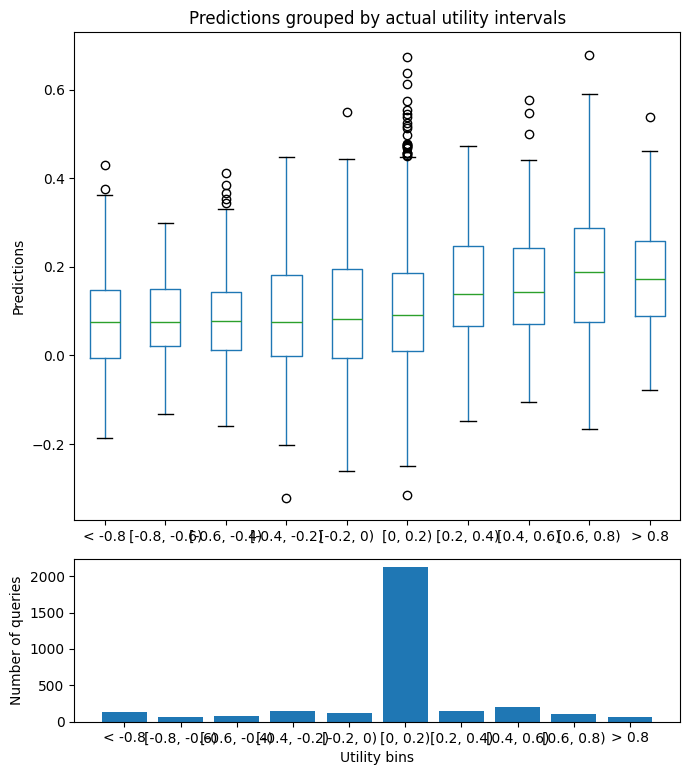

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

corr_df = pd.DataFrame(np.array([test_res.qid.values, test_res[target_metric].values, predictions_test]).T, columns=['qid', 'gt', 'pred'])
# Define bins and labels
# bins = [-1, -0.5, 0, 0.5, 1]
# labels = ["< -0.5", "[-0.5, 0)", "[0, 0.5)", "> 0.5"]

bins = [-1, -0.8, -0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8, 1]
labels = ["< -0.8", "[-0.8, -0.6)", "[-0.6, -0.4)", "[-0.4, -0.2)", "[-0.2, 0)", "[0, 0.2)", "[0.2, 0.4)", "[0.4, 0.6)", "[0.6, 0.8)", "> 0.8"]

# Assign bins
corr_df["gt_bin"] = pd.cut(corr_df["gt"], bins=bins, labels=labels, right=False)

# Prepare subplots
fig, axes = plt.subplots(2, 1, figsize=(7, 8), gridspec_kw={'height_ratios': [3, 1]})

# --- Boxplot of predictions grouped by bins ---
corr_df.boxplot(column="pred", by="gt_bin", grid=False, ax=axes[0])
axes[0].set_title("Predictions grouped by actual utility intervals")
axes[0].set_xlabel("")
axes[0].set_ylabel("Predictions")
axes[0].get_figure().suptitle("")  # remove automatic title

# --- Histogram (counts of queries in each bin) ---
counts = corr_df["gt_bin"].value_counts().reindex(labels)  # preserve bin order
axes[1].bar(counts.index, counts.values)
axes[1].set_xlabel("Utility bins")
axes[1].set_ylabel("Number of queries")

plt.tight_layout()
plt.show()

In [11]:
corr_df[corr_df.pred<0].count()

qid       683
gt        683
pred      683
gt_bin    650
dtype: int64

In [12]:
import numpy as np
import numpy as np
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score

dev_res['pred'] = predictions

# Search over possible thresholds
thresholds = np.linspace(min(predictions), max(predictions), 10)
best_thr, opt_removed_utility = None, 1000000

# for thr in thresholds:
#     removed_utility = dev_res[dev_res.pred<thr].utility.sum()
#     if removed_utility < opt_removed_utility:
#         opt_removed_utility = removed_utility
#         best_thr = thr

# print(f"Best threshold on dev: {best_thr:.3f}")

# not working, the distribution may be different
positive_rank = dev_res[dev_res.utility>-0].shape[0]
sorted_preds = np.sort(predictions)[::-1]
best_thr = sorted_preds[positive_rank - 1]
print(best_thr)

# # not working
# real_neg_qids = dev_res[dev_res.utility<0].qid.values
# temp_df = pd.DataFrame(np.array([dev_res.qid.values, predictions]).T, columns=['qid', 'preds'])
# best_thr = temp_df[temp_df.qid.isin(real_neg_qids)].preds.mean()
# print(threshold)

neg_qids = corr_df[corr_df['pred'] < best_thr].qid.values
# print(test_res.utility.mean())
# print(test_res[test_res.qid.isin(neg_qids)].utility.mean())
mask = test_res['qid'].isin(neg_qids)
test_res['optimised_f1'] = np.where(mask,
                                    test_res['f1'] - test_res['utility'],
                                    test_res['f1'])

test_res['zero_f1'] = test_res['f1']-test_res['utility']
test_res['oracle_f1'] = np.max([test_res['zero_f1'], test_res['f1']], axis=0)
print(test_res['oracle_f1'].mean())
print(test_res['zero_f1'].mean())
print(test_res['optimised_f1'].mean())
print(test_res['f1'].mean())
# test_res['optimised_f1'] = test_res.qid.apply(lambda x: test_res.f1-test_res.utility if (x in neg_qids) else test_res.f1)

0.19629923632151858
0.40570537191850947
0.21494989292372776
0.28882022573736793
0.32844919315833443


In [15]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

binary_df = corr_df.copy()

# for thr in np.linspace(min(predictions_test), max(predictions_test), 10):
for thr in np.linspace(-1, 1, 20):
    
    # print(thr)
    neg_qids = corr_df[corr_df['pred'] < thr].qid.values
    # print(3610-len(neg_qids))
    test_res['optimised_f1'] = test_res['f1'] - test_res['utility']*(test_res['qid'].isin(neg_qids))
    # print(test_res['optimised_f1'].min())
    
    test_res['zero_f1'] = test_res['f1']-test_res['utility']
    test_res['oracle_f1'] = np.max([test_res['zero_f1'], test_res['f1']], axis=0)
    # print(test_res['optimised_f1'].mean())

    binary_df["label"] = (binary_df["gt"] > thr).astype(int)
    y_true = binary_df["label"].values
    y_pred = binary_df["pred"].values
    
    # Metrics
    auc = roc_auc_score(y_true, y_pred)
    
    print(f"ROC-AUC: {auc:.3f}")

print('--------------')
print(test_res['oracle_f1'].mean())
print(test_res['zero_f1'].mean())
print(test_res['f1'].mean())

ROC-AUC: 0.581
ROC-AUC: 0.581
ROC-AUC: 0.580
ROC-AUC: 0.577
ROC-AUC: 0.586
ROC-AUC: 0.585
ROC-AUC: 0.583
ROC-AUC: 0.586
ROC-AUC: 0.579
ROC-AUC: 0.579
ROC-AUC: 0.653
ROC-AUC: 0.658
ROC-AUC: 0.666
ROC-AUC: 0.664
ROC-AUC: 0.669
ROC-AUC: 0.673
ROC-AUC: 0.675
ROC-AUC: 0.672
ROC-AUC: 0.677
ROC-AUC: nan
--------------
0.40570537191850947
0.21494989292372776
0.32844919315833443


/opt/miniconda3/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


In [16]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

binary_df = corr_df.copy()

thr = 0
# for thr in np.linspace(min(predictions_test), max(predictions_test), 10):
for x in np.linspace(0, 1, 10):
    binary_df = corr_df[(corr_df["gt"] <= -x) | (corr_df["gt"] > x)].copy()
    
    # print(thr)
    neg_qids = corr_df[corr_df['pred'] < thr].qid.values
    # print(3610-len(neg_qids))
    test_res['optimised_f1'] = test_res['f1'] - test_res['utility']*(test_res['qid'].isin(neg_qids))
    # print(test_res['optimised_f1'].min())
    
    test_res['zero_f1'] = test_res['f1']-test_res['utility']
    test_res['oracle_f1'] = np.max([test_res['zero_f1'], test_res['f1']], axis=0)
    # print(test_res['optimised_f1'].mean())

    binary_df["label"] = (binary_df["gt"] > thr).astype(int)
    y_true = binary_df["label"].values
    y_pred = binary_df["pred"].values
    
    # Metrics
    auc = roc_auc_score(y_true, y_pred)
    
    print(f"ROC-AUC: {auc:.3f}")

print('--------------')
print(test_res['oracle_f1'].mean())
print(test_res['zero_f1'].mean())
print(test_res['f1'].mean())

ROC-AUC: 0.653
ROC-AUC: 0.685
ROC-AUC: 0.691
ROC-AUC: 0.704
ROC-AUC: 0.714
ROC-AUC: 0.723
ROC-AUC: 0.733
ROC-AUC: 0.723
ROC-AUC: 0.726
ROC-AUC: nan
--------------
0.40570537191850947
0.21494989292372776
0.32844919315833443


/opt/miniconda3/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


In [24]:
corr_df["gt"].min()

-1.0

In [14]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Filter data: keep only gt < -0.5 or gt > 0.5
for x in np.arange(0, 1, 0.1):
    print(x)
    binary_df = corr_df[(corr_df["gt"] <= -x) | (corr_df["gt"] > x)].copy()
    binary_df = binary_df.copy()
    
    # Define ground-truth labels: 0 = low utility, 1 = high utility
    binary_df["label"] = (binary_df["gt"] > 0).astype(int)
    print(binary_df.shape)
    
    # Predictions (your continuous predictor)
    y_true = binary_df["label"].values
    y_pred = binary_df["pred"].values
    
    y_hat = (y_pred > best_thr).astype(int)
    
    # Metrics
    acc = accuracy_score(y_true, y_hat)
    f1 = f1_score(y_true, y_hat)
    auc = roc_auc_score(y_true, y_pred)
    
    print(f"Accuracy: {acc:.3f}")
    print(f"F1-score: {f1:.3f}")
    print(f"ROC-AUC: {auc:.3f}")

0.0
(3610, 5)


NameError: name 'y_hat' is not defined

In [384]:
np.mean(list(base_f1_dict.values()))

0.2149498929237277

In [329]:
from tools import fisher_test

In [330]:
fisher_test.compare_spearman_rhos(test_data.shape[0], 0.2139, 0.2606)

{'z_stat': -2.8873602288094014, 'p_value': 0.0038848916841072167}

### Random Forest

In [40]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# X_train, X_val, y_train, y_val = train_test_split(
#     dev_data, y, dev_data, random_state=42

rf = RandomForestRegressor(
    n_estimators=400,
    criterion='squared_error', # can be squared_error, absolute_error
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

rf.fit(dev_data, dev_res[target_metric].values)

RandomForestRegressor(max_features='sqrt', n_estimators=400, n_jobs=-1,
                      random_state=42)

In [41]:
predictions_from_rf = rf.predict(test_data)
result_rho, result_tau = stats.spearmanr(predictions_from_rf, test_res[target_metric])[0], stats.kendalltau(predictions_from_rf, test_res[target_metric])[0]

In [42]:
result_rho, result_tau

(0.24264941570861767, 0.18313069199883011)

In [43]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer
from scipy.stats import randint

def spearman_corr(y_true, y_pred):
    # Spearmanr returns (correlation, pvalue)
    return stats.spearmanr(y_true, y_pred).correlation

spearman_scorer = make_scorer(spearman_corr, greater_is_better=True)

param_dist = {
    "n_estimators": randint(200, 800),
    "max_depth": randint(3, 30),
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 10),
    # "max_features": ["sqrt", "log2", None]
    "max_features": ["sqrt"]
}

search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=40,
    scoring=spearman_scorer,   # <-- key difference
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1 # 2 for printing per-iteration results, 1 for simple display
)

search.fit(dev_data, dev_res[target_metric].values)
print("Best Spearman rho (CV):", search.best_score_)
print("Best params:", search.best_params_)
best_model = search.best_estimator_

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best Spearman rho (CV): 0.28082857926804317
Best params: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 6, 'n_estimators': 417}


In [44]:
predictions_from_best_rf = best_model.predict(test_data)
result_rho, result_tau = stats.spearmanr(predictions_from_best_rf, test_res[target_metric])[0], stats.kendalltau(predictions_from_best_rf, test_res[target_metric])[0]

In [45]:
result_rho, result_tau

(0.29557560023467483, 0.22451743129027374)

### Correlations between predictions

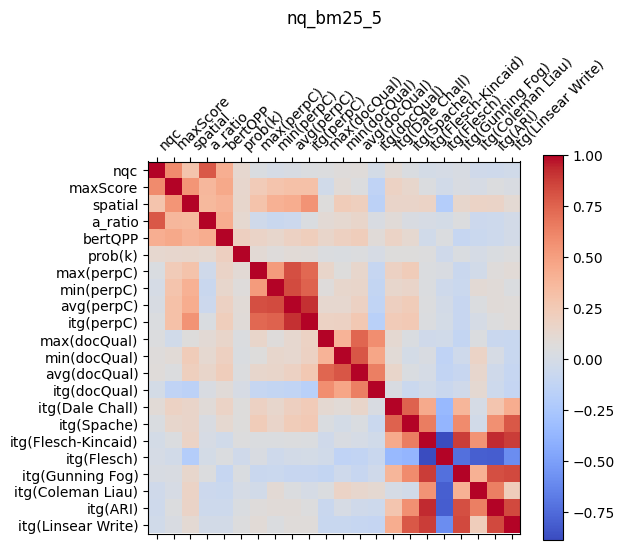

In [50]:
import pandas as pd
import matplotlib.pyplot as plt

# Example: suppose df has predictor columns
# df = pd.DataFrame({
#     "pred1": [0.1, 0.2, 0.3],
#     "pred2": [0.2, 0.1, 0.4],
#     "pred3": [0.3, 0.4, 0.5],
# })
# Compute correlation matrix
corr = test_res.drop(columns=['qid', 'query', 'f1', 'utility', 'bertQPP(QV)']).corr(method="spearman")

# Plot heatmap using matplotlib
fig, ax = plt.subplots(figsize=(6, 5))
cax = ax.matshow(corr, cmap="coolwarm")

# Add colorbar
fig.colorbar(cax)

# Set ticks and labels
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="left")
ax.set_yticklabels(corr.columns)

plt.title(f'{_task}_{_ret}_{_k}', pad=20)
plt.savefig(f"./plotting/heatmaps/heatmap_{_task}_{_ret}_{_k}_v1.png", format="png", bbox_inches="tight")  
plt.savefig(f"./plotting/heatmaps/heatmap_{_task}_{_ret}_{_k}_v1.pdf", format="pdf", bbox_inches="tight")  
plt.show()